In [ ]:
# NIKE SALES DATA ANALYSIS PROJECT

### Student Names: P.Ganesh,S.Sai kumar,T.Indravathi,S.Jyothirmayi,M.Anjali
### Course: Data Analytics
### Tools: Python, Pandas, NumPy, Matplotlib, Seaborn
### Objective: Transform raw Nike sales data into business insights
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
df = pd.read_csv("Nike_Sales_Uncleaned.csv")
df.head()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Nike_Sales_Uncleaned.csv to Nike_Sales_Uncleaned.csv


In [ ]:
# Shape
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns)

# Info
df.info()

# Statistical Summary
df.describe()

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

Shape: (2500, 13)
Columns: Index(['Order_ID', 'Gender_Category', 'Product_Line', 'Product_Name', 'Size',
       'Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Order_Date',
       'Sales_Channel', 'Region', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null 

np.int64(0)

In [ ]:
# Unique values
df.nunique()

# Check negative values
df[df['Units_Sold'] < 0]

# Check invalid prices
df[df['MRP'] <= 0]

# Check profit issues
df[df['Profit'] < 0].head()

# Clean column names
df.columns = df.columns.str.strip()

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Fix data types
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='mixed', dayfirst=True)

# Clean text columns
df['Region'] = df['Region'].str.strip().str.title()
df['Sales_Channel'] = df['Sales_Channel'].str.strip().str.title()
df['Gender_Category'] = df['Gender_Category'].str.strip().str.title()

In [ ]:
# Create Discount Value
df['Discount_Value'] = df['MRP'] * df['Discount_Applied'] / 100

# Extract Date Features
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')
df['Year'] = df['Order_Date'].dt.year

In [ ]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_units = df['Units_Sold'].sum()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Units Sold:", total_units)

Total Revenue: 427503.51
Total Profit: 164980.86
Total Units Sold: 201.0


In [ ]:
monthly_sales = df.groupby('Month_Name')['Revenue'].sum().reset_index()

months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_sales['Month_Name'] = pd.Categorical(
    monthly_sales['Month_Name'],
    categories=months_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month_Name')
monthly_sales

,Month_Name,Revenue
4,Jan,42677.46
3,Feb,18288.83
7,Mar,25681.45
0,Apr,51880.41
8,May,37829.24
6,Jun,29207.78
5,Jul,20658.78
1,Aug,21835.08
11,Sep,61029.27
10,Oct,17526.84


In [ ]:
top_products = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

,Revenue
Product_Name,
LeBron 20,42527.70
Flex Trainer,41692.48
ZoomX Invincible,39123.81
Air Force 1,34041.68
Premier III,32679.09
Metcon 7,31746.19
Tiempo Legend,23666.82
Dunk Low,23598.52
SuperRep Go,22191.09


In [ ]:
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
region_sales

,Revenue
Region,
Kolkata,100534.03
Hyderbad,66209.99
Pune,63841.33
Mumbai,61226.41
Delhi,41863.54
Bengaluru,38679.76
Bangalore,33548.61
Hyderabad,20952.94
Hyd,646.90


In [ ]:
region_sales = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
region_sales

,Revenue
Region,
Kolkata,100534.03
Hyderbad,66209.99
Pune,63841.33
Mumbai,61226.41
Delhi,41863.54
Bengaluru,38679.76
Bangalore,33548.61
Hyderabad,20952.94
Hyd,646.90


In [ ]:
channel_sales = df.groupby('Sales_Channel')['Revenue'].sum()
channel_sales

,Revenue
Sales_Channel,
Online,225888.17
Retail,201615.34


In [ ]:
profit_analysis = df.groupby('Product_Line')['Profit'].sum().sort_values(ascending=False)
profit_analysis

,Profit
Product_Line,
Soccer,48098.18
Basketball,42415.01
Running,28077.19
Lifestyle,27101.28
Training,19289.20


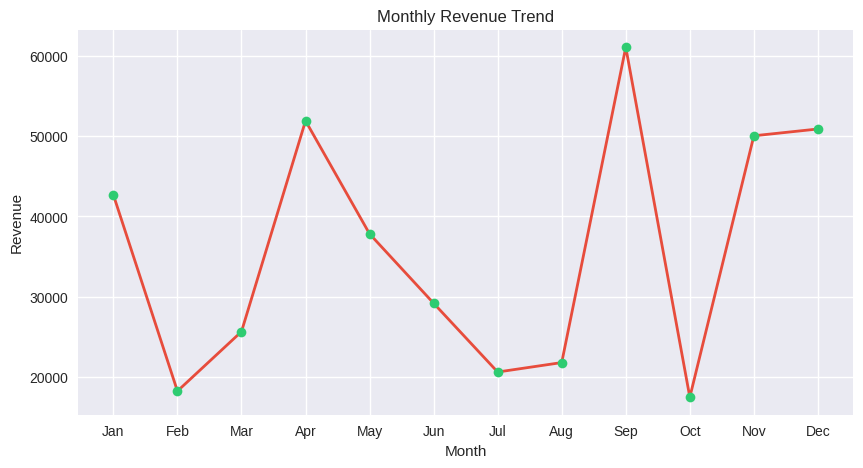

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month_Name'],
         monthly_sales['Revenue'],
         marker='o',
         color='#E74C3C',        # line color (red)
         markerfacecolor='#2ECC71',  # marker fill (green)
         markeredgecolor='#2C3E50',  # marker border (dark)
         linewidth=2)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

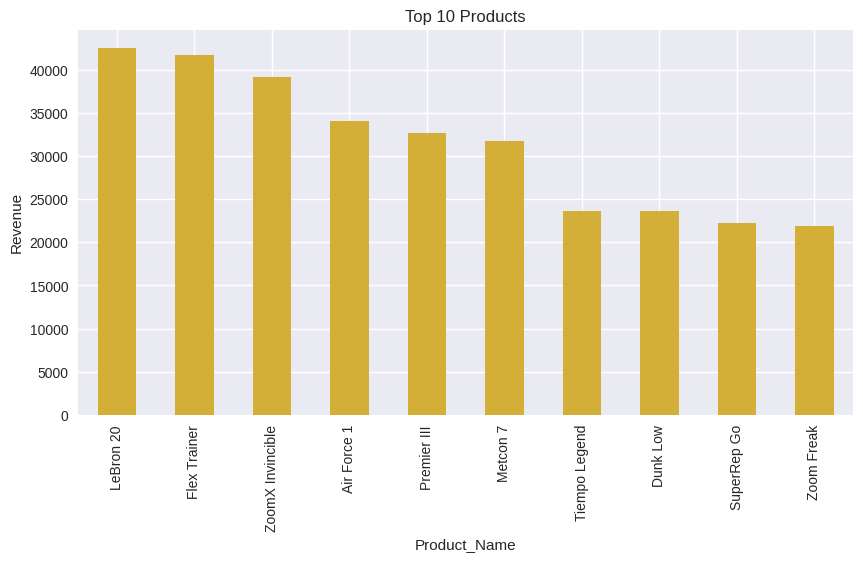

In [ ]:
top_products.plot(kind='bar', figsize=(10,5), color='#D4AF37')
plt.title("Top 10 Products")
plt.ylabel("Revenue")
plt.show()

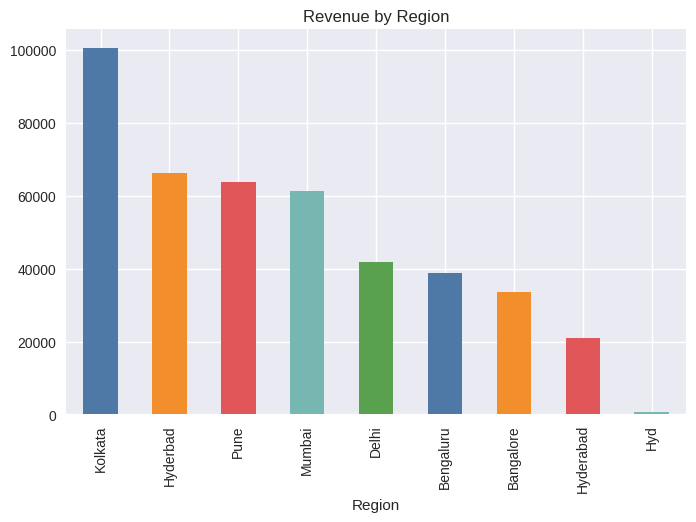

In [ ]:
region_sales.plot(kind='bar', figsize=(8,5), color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'])
plt.title("Revenue by Region")
plt.show()

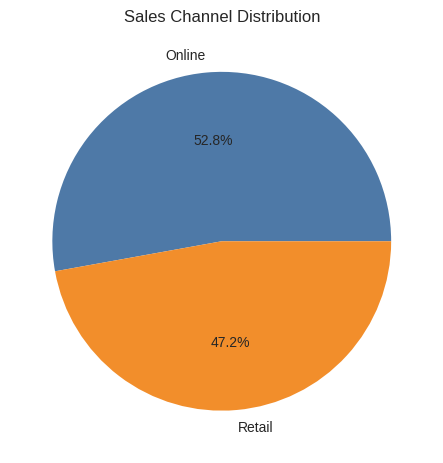

In [ ]:
plt.pie(channel_sales,
        labels=channel_sales.index,
        autopct='%1.1f%%',
        colors=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F'])

plt.title("Sales Channel Distribution")
plt.show()

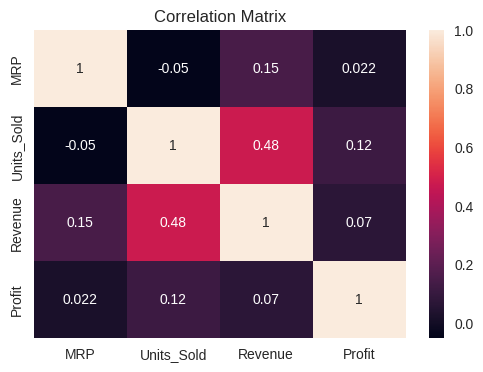

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[['MRP','Units_Sold','Revenue','Profit']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

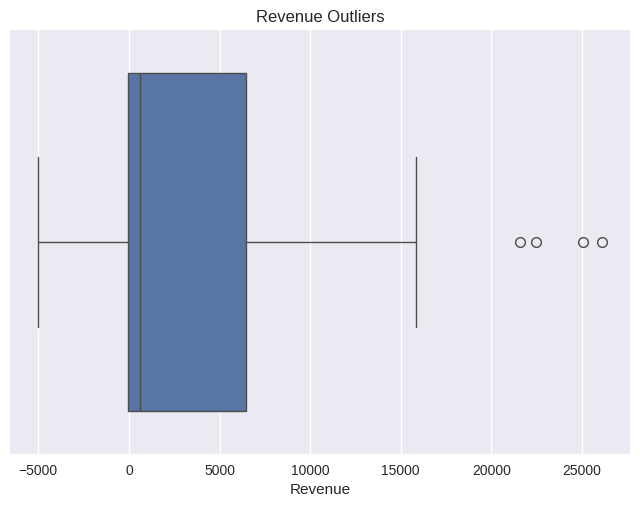

In [ ]:
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Outliers")
plt.show()